#ROC

Model's ROC curve values:
FPR (False Positive Rate): [0. 0. 1.]
TPR (True Positive Rate): [0. 1. 1.]
Thresholds: [inf  1.  0.]
Model's AUC: 1.00


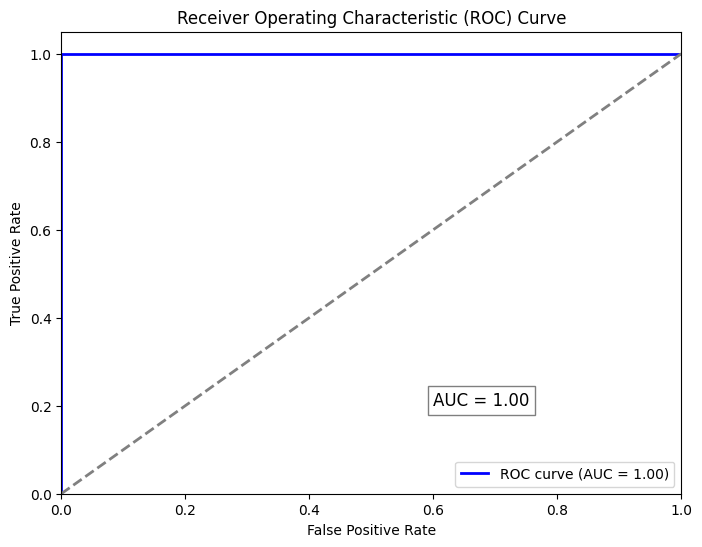

In [ ]:
#1.SVM
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Load confusion matrix from the image (manually extracted key values)
# The confusion matrix is assumed to be square with labels on both axes

# Extracted matrix from the image (simplified version)
conf_matrix = np.array([
    [233, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 224, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 223, 0, 0, 0, 10, 0, 0, 0, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1],
    [0, 0, 0, 97, 0, 8, 0, 0, 0, 0, 6, 3, 8, 0, 14, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 3, 0, 0, 0, 41, 0, 10, 1, 0, 6, 0],
    [0, 0, 0, 0, 204, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 4, 17, 1, 22, 1, 0, 0, 3, 0, 2, 10, 1, 5, 30, 13, 0, 7, 0, 0, 4, 15, 0, 2, 14, 2, 9, 0, 7, 1, 1, 16, 0, 4, 0, 0, 0, 1, 10],
    [0, 0, 0, 0, 0, 0, 206, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 228, 0, 0, 0, 0, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 206, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 221, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 8, 0, 0, 0, 0, 0, 0, 154, 0, 1, 0, 0, 2, 3, 0, 0, 0, 0, 5, 0, 0, 3, 0, 0, 0, 0, 12, 1, 0, 3, 0, 0, 0, 0, 9, 0, 0],
    [0, 0, 0, 2, 0, 0, 6, 0, 0, 0, 2, 154, 0, 3, 18, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 7, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 8, 3, 0, 0, 0, 170, 0, 0, 1, 2, 0, 0, 0, 0, 1, 7, 0, 0, 0, 0, 0, 0, 3, 0, 3, 1, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 238, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 6, 0, 0, 0, 0, 4, 0, 4, 0, 177, 1, 1, 0, 0, 0, 2, 6, 0, 0, 2, 0, 0, 0, 0, 3, 0, 0, 0, 1, 0, 0, 0, 1, 9, 2],
    [1, 0, 0, 0, 0, 15, 0, 0, 1, 0, 16, 0, 28, 2, 1, 97, 0, 0, 1, 0, 0, 1, 0, 0, 2, 23, 0, 0, 0, 4, 0, 0, 0, 0, 0, 33, 2, 0, 0, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 220, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 2],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 229, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 31, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 171, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 221, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 12, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 212, 0, 1, 0, 0, 1, 0, 2, 1, 0, 3, 0, 4, 3, 0, 0, 2, 2, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 206, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 3, 3, 0, 0, 0, 0, 1, 2],
    [0, 0, 0, 0, 1, 5, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 6, 0, 104, 21, 0, 2, 1, 1, 0, 0, 15, 0, 9, 27, 0, 7, 18, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 200, 0, 0, 0, 2, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 5, 0, 1, 0, 29, 0, 5, 0, 0, 0, 0, 0, 0, 0, 175, 1, 0, 0, 0, 0, 0, 0, 0, 8, 0, 1, 0, 0, 3, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 11, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 213, 1, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 10, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 9, 0, 0, 0, 0, 1, 186, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 2, 10, 0, 0, 0, 0, 6, 0, 0, 0, 0, 1, 0, 0, 2, 0, 3, 0, 11, 26, 0, 2, 0, 117, 6, 0, 5, 13, 0, 23, 1, 1, 0, 0, 6, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 12, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 211, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 3, 1, 0, 0, 0, 0, 0, 0, 3, 0, 3, 0, 0, 0, 0, 0, 0, 179, 0, 0, 0, 1, 3, 0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 213, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 236, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 219, 1, 1, 1, 1, 0, 0, 0],
    [0, 0, 0, 8, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 4, 0, 0, 0, 0, 15, 43, 0, 12, 0, 0, 7, 7, 2, 9, 8, 0, 107, 0, 0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 231, 0, 0, 0, 0, 0],
    [2, 0, 4, 0, 4, 0, 0, 0, 5, 13, 0, 1, 0, 9, 1, 6, 21, 0, 0, 0, 0, 4, 3, 0, 2, 0, 4, 1, 0, 0, 1, 9, 0, 0, 0, 129, 5, 0, 0, 10],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 215, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 220, 0, 0],
    [0, 0, 0, 40, 0, 0, 3, 2, 1, 0, 0, 14, 1, 2, 36, 0, 4, 0, 0, 0, 0, 13, 1, 20, 22, 0, 9, 34, 2, 3, 0, 7, 0, 0, 0, 0, 0, 0, 7, 21],
    [0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 5, 0, 4, 0, 19, 0, 0, 0, 0, 1, 3, 6, 0, 0, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 9, 0, 0, 1, 170]
])


# Create true labels from the confusion matrix
true_labels = np.repeat(np.arange(conf_matrix.shape[0]), conf_matrix.sum(axis=1))

# Create predicted labels based on the confusion matrix
predicted_labels = np.array([i for i in range(conf_matrix.shape[0]) for _ in range(conf_matrix[i, :].sum())])

# Binarize the true and predicted labels
y_true_bin = label_binarize(true_labels, classes=np.arange(conf_matrix.shape[0]))
y_pred_bin = label_binarize(predicted_labels, classes=np.arange(conf_matrix.shape[0]))

# Calculate ROC curve and AUC (model-level, One-vs-Rest)
fpr, tpr, thresholds = roc_curve(y_true_bin.ravel(), y_pred_bin.ravel())
roc_auc = auc(fpr, tpr)

# Print the model's ROC and AUC values
print("Model's ROC curve values:")
print(f"FPR (False Positive Rate): {fpr}")
print(f"TPR (True Positive Rate): {tpr}")
print(f"Thresholds: {thresholds}")

# Print the AUC value
print(f"Model's AUC: {roc_auc:.2f}")

# Plot the ROC curve for the model
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')

# Plot a diagonal line for the random classifier
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

# Customize the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')

# Add AUC value text inside the plot area
plt.text(0.6, 0.2, f'AUC = {roc_auc:.2f}', color='black', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

# Display the plot
plt.legend(loc='lower right')
plt.show()

Model's ROC curve values:
FPR (False Positive Rate): [0. 0. 1.]
TPR (True Positive Rate): [0. 1. 1.]
Thresholds: [inf  1.  0.]
Model's AUC: 1.00


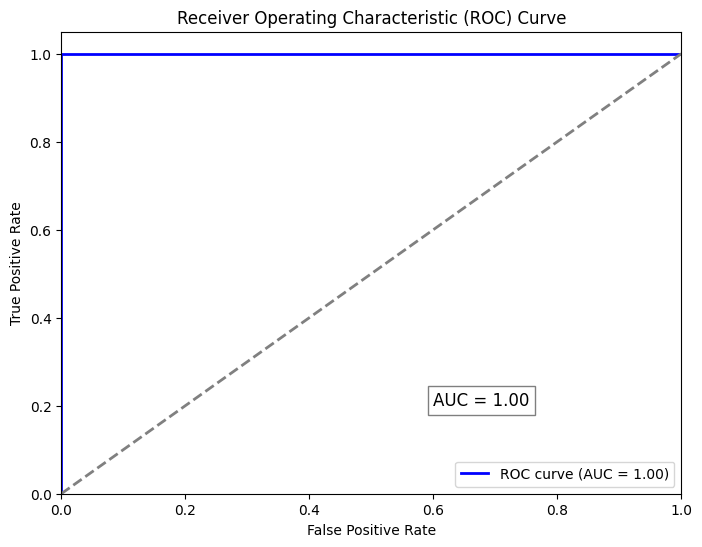

In [ ]:
#2.LR
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Load confusion matrix from the image (manually extracted key values)
# The confusion matrix is assumed to be square with labels on both axes

# Extracted matrix from the image (simplified version)
conf_matrix = np.array([
    [233, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 224, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 223, 0, 0, 0, 10, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 118, 0, 10, 0, 0, 0, 0, 7, 3, 6, 0, 2, 0, 1, 1, 0, 3, 1, 1, 0, 0, 0, 1, 0, 0, 0, 3, 0, 0, 0, 37, 0, 8, 1, 0, 1, 0],
    [0, 0, 0, 0, 202, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 10, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 5, 17, 1, 22, 1, 1, 0, 3, 0, 3, 11, 1, 2, 30, 14, 1, 6, 0, 0, 6, 17, 0, 2, 14, 2, 6, 0, 7, 1, 1, 16, 0, 4, 2, 0, 0, 0, 6],
    [0, 0, 0, 0, 0, 0, 210, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 225, 0, 0, 0, 0, 10, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 209, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 221, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [2, 0, 6, 0, 0, 0, 0, 0, 0, 0, 161, 0, 0, 0, 1, 1, 2, 0, 0, 0, 0, 3, 0, 0, 1, 0, 0, 0, 0, 12, 1, 0, 1, 0, 0, 0, 0, 10, 0, 0],
    [0, 0, 0, 3, 0, 2, 3, 0, 0, 0, 2, 172, 0, 4, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 4, 0, 0, 0, 3, 0, 2, 0, 0, 0, 0],
    [2, 0, 0, 2, 0, 0, 0, 6, 3, 0, 0, 0, 174, 0, 0, 2, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 3, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 238, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [9, 0, 6, 2, 0, 15, 0, 0, 0, 0, 7, 0, 11, 0, 132, 3, 4, 0, 0, 0, 2, 11, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 3, 0, 3, 0, 4, 2, 2],
    [1, 0, 0, 0, 0, 18, 0, 0, 1, 0, 21, 0, 26, 2, 0, 98, 0, 0, 1, 0, 0, 0, 0, 0, 0, 24, 0, 0, 0, 4, 0, 0, 0, 0, 0, 28, 3, 0, 0, 1],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 2, 0, 2, 218, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 229, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 26, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 176, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 221, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 12, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 214, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 199, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 3, 3, 0, 2, 0, 0, 0, 8],
    [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 1, 0, 2, 0, 0, 1, 0, 0, 0, 0, 5, 0, 116, 22, 0, 1, 1, 1, 0, 0, 15, 0, 8, 16, 0, 7, 20, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 203, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [8, 0, 0, 2, 0, 6, 0, 0, 0, 0, 6, 0, 3, 0, 0, 0, 15, 0, 0, 0, 0, 0, 0, 0, 177, 0, 0, 0, 0, 0, 0, 0, 0, 8, 0, 1, 0, 0, 4, 2],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 2, 215, 3, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 9, 0, 0, 0, 0, 0, 190, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 3, 7, 0, 0, 0, 0, 5, 0, 0, 0, 0, 1, 0, 0, 2, 0, 3, 0, 13, 27, 0, 2, 0, 120, 5, 0, 5, 22, 0, 18, 1, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 12, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 218, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0],
    [3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 3, 1, 0, 0, 0, 0, 0, 0, 3, 0, 3, 0, 0, 0, 0, 0, 0, 166, 0, 0, 0, 2, 3, 0, 0, 0, 0, 4],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 213, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 236, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 223, 1, 1, 1, 1, 0, 0, 0],
    [0, 0, 0, 10, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 5, 0, 0, 0, 0, 14, 50, 0, 13, 0, 0, 9, 8, 1, 9, 11, 0, 94, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 231, 0, 0, 0, 0, 0],
    [2, 0, 3, 4, 5, 1, 0, 0, 5, 13, 0, 0, 0, 9, 0, 10, 20, 2, 0, 0, 0, 1, 4, 0, 2, 0, 2, 2, 0, 0, 1, 9, 0, 0, 1, 119, 6, 0, 0, 13],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 215, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 220, 0, 0],
    [5, 0, 0, 39, 0, 0, 2, 2, 2, 0, 0, 15, 0, 2, 32, 0, 6, 0, 0, 0, 0, 12, 0, 21, 22, 0, 9, 33, 1, 2, 0, 8, 0, 0, 0, 0, 0, 0, 7, 22],
    [2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 5, 0, 8, 0, 0, 0, 0, 0, 0, 1, 5, 6, 0, 0, 3, 0, 0, 0, 0, 3, 0, 0, 0, 1, 0, 8, 0, 0, 0, 182]
])


# Create true labels from the confusion matrix
true_labels = np.repeat(np.arange(conf_matrix.shape[0]), conf_matrix.sum(axis=1))

# Create predicted labels based on the confusion matrix
predicted_labels = np.array([i for i in range(conf_matrix.shape[0]) for _ in range(conf_matrix[i, :].sum())])

# Binarize the true and predicted labels
y_true_bin = label_binarize(true_labels, classes=np.arange(conf_matrix.shape[0]))
y_pred_bin = label_binarize(predicted_labels, classes=np.arange(conf_matrix.shape[0]))

# Calculate ROC curve and AUC (model-level, One-vs-Rest)
fpr, tpr, thresholds = roc_curve(y_true_bin.ravel(), y_pred_bin.ravel())
roc_auc = auc(fpr, tpr)

# Print the model's ROC and AUC values
print("Model's ROC curve values:")
print(f"FPR (False Positive Rate): {fpr}")
print(f"TPR (True Positive Rate): {tpr}")
print(f"Thresholds: {thresholds}")

# Print the AUC value
print(f"Model's AUC: {roc_auc:.2f}")

# Plot the ROC curve for the model
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')

# Plot a diagonal line for the random classifier
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

# Customize the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')

# Add AUC value text inside the plot area
plt.text(0.6, 0.2, f'AUC = {roc_auc:.2f}', color='black', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

# Display the plot
plt.legend(loc='lower right')
plt.show()

Model's ROC curve values:
FPR (False Positive Rate): [0. 0. 1.]
TPR (True Positive Rate): [0. 1. 1.]
Thresholds: [inf  1.  0.]
Model's AUC: 1.00


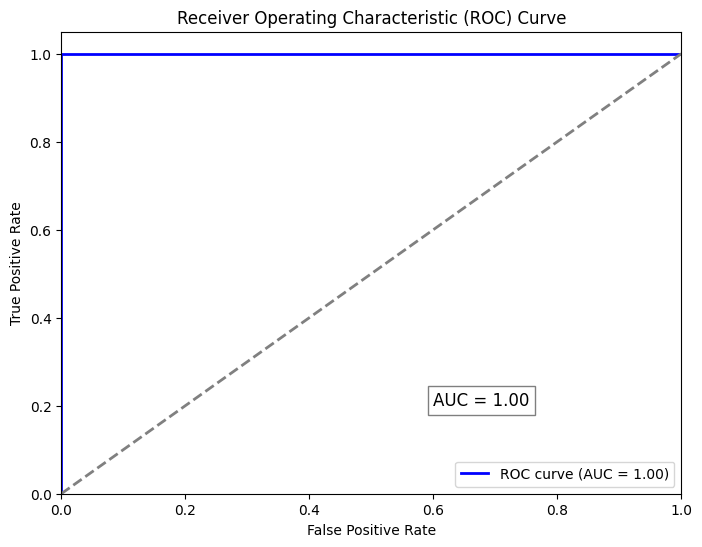

In [ ]:
#3.RF
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Load confusion matrix from the image (manually extracted key values)
# The confusion matrix is assumed to be square with labels on both axes

# Extracted matrix from the image (simplified version)
conf_matrix = np.array([
    [231, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 224, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 223, 0, 0, 0, 10, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 101, 0, 14, 0, 0, 0, 0, 7, 3, 6, 0, 2, 0, 0, 0, 0, 3, 1, 1, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 47, 0, 8, 1, 0, 6, 0],
    [0, 0, 0, 0, 196, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 15, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 0, 4, 12, 1, 25, 1, 0, 0, 3, 0, 3, 8, 1, 5, 35, 14, 0, 6, 0, 0, 4, 16, 0, 2, 13, 2, 5, 0, 7, 1, 1, 17, 2, 4, 1, 0, 0, 0, 8],
    [0, 0, 0, 0, 0, 0, 209, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 229, 0, 0, 0, 0, 10, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 210, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 221, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 178, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 5, 0, 0, 1, 0, 0, 0, 0, 8, 0, 0],
    [0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 180, 0, 2, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 3, 0, 0, 0, 5, 0, 2, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 8, 1, 0, 0, 0, 180, 0, 0, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 238, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 4, 0, 0, 11, 0, 0, 0, 0, 6, 0, 6, 0, 155, 2, 4, 0, 0, 0, 2, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 18, 0, 3, 0, 0, 1, 1],
    [3, 0, 0, 0, 0, 11, 0, 0, 2, 0, 21, 0, 25, 2, 1, 104, 0, 0, 0, 0, 0, 0, 0, 0, 0, 23, 0, 0, 0, 5, 0, 0, 0, 0, 0, 28, 2, 0, 0, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 3, 0, 3, 217, 0, 0, 0, 2, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 228, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 21, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 179, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 221, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 220, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 212, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 1, 0, 0, 0, 4, 0, 102, 22, 0, 1, 1, 0, 0, 0, 14, 0, 9, 34, 0, 6, 18, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 196, 0, 0, 0, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 1, 0, 4, 0, 0, 0, 0, 4, 0, 3, 0, 1, 0, 9, 0, 0, 0, 0, 0, 0, 0, 186, 1, 0, 0, 0, 0, 0, 0, 0, 23, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 219, 1, 0, 0, 2, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 6, 0, 0, 0, 0, 1, 190, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 8, 8, 0, 0, 0, 0, 6, 0, 0, 0, 1, 0, 0, 0, 2, 0, 3, 0, 6, 27, 0, 0, 0, 109, 5, 0, 7, 14, 0, 33, 0, 4, 0, 0, 2, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 214, 0, 0, 0, 0, 9, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 2, 2, 3, 0, 1, 1, 0, 0, 0, 3, 0, 1, 0, 0, 2, 0, 0, 0, 171, 0, 0, 0, 2, 3, 0, 0, 0, 0, 5],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 212, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 229, 0, 7, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 221, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 3, 0, 0, 0, 0, 13, 32, 0, 6, 0, 0, 1, 9, 1, 9, 8, 0, 138, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 231, 0, 0, 0, 0, 0],
    [1, 0, 2, 0, 6, 0, 0, 0, 3, 13, 0, 0, 0, 8, 0, 3, 19, 0, 0, 0, 0, 1, 1, 0, 3, 0, 1, 0, 0, 0, 0, 9, 0, 1, 0, 150, 5, 0, 0, 8],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 215, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 220, 0, 0],
    [0, 0, 0, 39, 0, 0, 2, 2, 2, 0, 0, 15, 0, 2, 35, 0, 4, 0, 0, 0, 0, 12, 0, 19, 23, 0, 9, 33, 2, 2, 0, 8, 0, 5, 0, 0, 0, 0, 6, 22],
    [0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 3, 0, 7, 0, 1, 0, 0, 0, 0, 1, 5, 6, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 5, 0, 8, 0, 0, 0, 184]
])


# Create true labels from the confusion matrix
true_labels = np.repeat(np.arange(conf_matrix.shape[0]), conf_matrix.sum(axis=1))

# Create predicted labels based on the confusion matrix
predicted_labels = np.array([i for i in range(conf_matrix.shape[0]) for _ in range(conf_matrix[i, :].sum())])

# Binarize the true and predicted labels
y_true_bin = label_binarize(true_labels, classes=np.arange(conf_matrix.shape[0]))
y_pred_bin = label_binarize(predicted_labels, classes=np.arange(conf_matrix.shape[0]))

# Calculate ROC curve and AUC (model-level, One-vs-Rest)
fpr, tpr, thresholds = roc_curve(y_true_bin.ravel(), y_pred_bin.ravel())
roc_auc = auc(fpr, tpr)

# Print the model's ROC and AUC values
print("Model's ROC curve values:")
print(f"FPR (False Positive Rate): {fpr}")
print(f"TPR (True Positive Rate): {tpr}")
print(f"Thresholds: {thresholds}")

# Print the AUC value
print(f"Model's AUC: {roc_auc:.2f}")

# Plot the ROC curve for the model
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')

# Plot a diagonal line for the random classifier
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

# Customize the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')

# Add AUC value text inside the plot area
plt.text(0.6, 0.2, f'AUC = {roc_auc:.2f}', color='black', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

# Display the plot
plt.legend(loc='lower right')
plt.show()

Model's ROC curve values:
FPR (False Positive Rate): [0. 0. 1.]
TPR (True Positive Rate): [0. 1. 1.]
Thresholds: [inf  1.  0.]
Model's AUC: 1.00


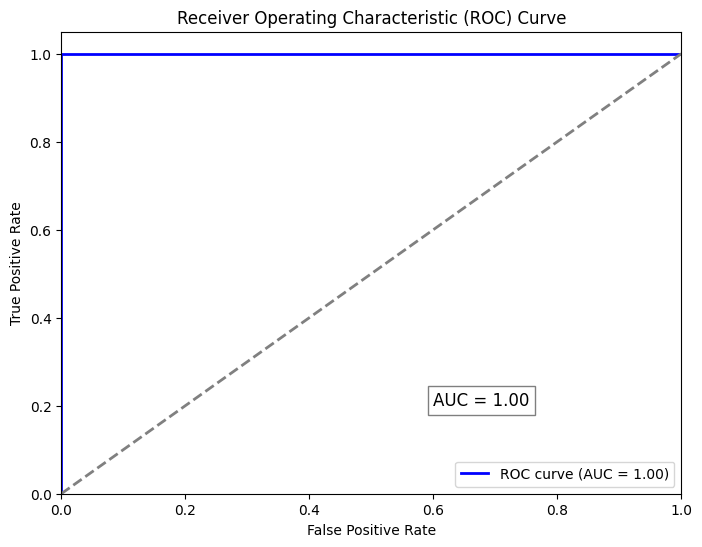

In [ ]:
#4.MLP
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Load confusion matrix from the image (manually extracted key values)
# The confusion matrix is assumed to be square with labels on both axes

# Extracted matrix from the image (simplified version)
conf_matrix = np.array([
    [233, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 224, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 229, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 122, 0, 8, 0, 0, 0, 0, 6, 4, 6, 0, 3, 0, 0, 0, 0, 1, 1, 0, 0, 1, 2, 0, 0, 0, 0, 2, 0, 0, 0, 35, 0, 6, 1, 0, 6, 0],
    [0, 0, 0, 0, 195, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 17, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 3, 16, 1, 53, 1, 0, 0, 3, 0, 2, 4, 1, 6, 23, 12, 0, 7, 0, 0, 3, 10, 0, 1, 13, 2, 10, 0, 6, 1, 0, 15, 0, 4, 0, 0, 0, 0, 5],
    [0, 0, 0, 0, 0, 0, 211, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 235, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 3, 0, 208, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 221, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 172, 1, 0, 0, 0, 5, 2, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 5, 0, 0, 1, 0, 0, 0, 0, 8, 0, 0],
    [0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 188, 0, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 9, 2, 0, 0, 0, 164, 0, 1, 13, 1, 0, 0, 0, 0, 1, 2, 0, 1, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 238, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 3, 0, 0, 0, 0, 2, 0, 1, 0, 180, 0, 0, 0, 0, 0, 2, 2, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 3, 0, 0, 0, 0, 22, 1],
    [1, 0, 0, 2, 0, 21, 0, 2, 2, 0, 17, 0, 15, 0, 0, 116, 0, 0, 0, 0, 0, 0, 0, 0, 0, 19, 0, 0, 0, 3, 0, 0, 0, 0, 0, 28, 2, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 223, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 3, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 229, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 18, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 184, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 221, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 3, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 216, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 6, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 208, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 2],
    [0, 0, 0, 0, 1, 15, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 89, 20, 0, 1, 1, 9, 0, 0, 14, 0, 7, 39, 0, 5, 15, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 202, 0, 0, 0, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 4, 0, 0, 0, 0, 3, 0, 0, 0, 8, 0, 2, 0, 0, 0, 0, 0, 0, 0, 196, 0, 0, 0, 0, 0, 0, 0, 0, 10, 0, 1, 0, 0, 7, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 218, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 1, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 6, 0, 0, 0, 0, 1, 191, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0],
    [0, 0, 0, 0, 3, 7, 0, 0, 0, 0, 5, 0, 0, 0, 0, 1, 0, 0, 2, 0, 3, 0, 13, 27, 0, 2, 0, 128, 5, 0, 4, 11, 0, 18, 0, 2, 0, 0, 15, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 220, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 5, 1, 0, 0, 1, 0, 0, 0, 0, 3, 0, 1, 0, 0, 0, 0, 0, 0, 184, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 213, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 233, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 222, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 13, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 4, 0, 0, 0, 0, 11, 26, 0, 12, 0, 0, 17, 6, 1, 9, 7, 0, 118, 0, 0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 231, 0, 0, 0, 0, 0],
    [2, 0, 1, 2, 1, 0, 0, 0, 3, 13, 0, 0, 0, 7, 2, 7, 18, 0, 0, 0, 0, 2, 1, 0, 2, 0, 1, 2, 0, 0, 1, 9, 1, 0, 0, 149, 4, 0, 0, 6],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 215, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 220, 0, 0],
    [5, 0, 0, 43, 0, 0, 3, 2, 1, 0, 0, 15, 0, 2, 33, 0, 6, 0, 0, 0, 0, 14, 1, 19, 22, 0, 9, 34, 2, 2, 0, 6, 0, 1, 0, 0, 0, 0, 7, 20],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 8, 0, 2, 0, 0, 1, 1, 2, 0, 0, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 6, 0, 0, 11, 186]
])


# Create true labels from the confusion matrix
true_labels = np.repeat(np.arange(conf_matrix.shape[0]), conf_matrix.sum(axis=1))

# Create predicted labels based on the confusion matrix
predicted_labels = np.array([i for i in range(conf_matrix.shape[0]) for _ in range(conf_matrix[i, :].sum())])

# Binarize the true and predicted labels
y_true_bin = label_binarize(true_labels, classes=np.arange(conf_matrix.shape[0]))
y_pred_bin = label_binarize(predicted_labels, classes=np.arange(conf_matrix.shape[0]))

# Calculate ROC curve and AUC (model-level, One-vs-Rest)
fpr, tpr, thresholds = roc_curve(y_true_bin.ravel(), y_pred_bin.ravel())
roc_auc = auc(fpr, tpr)

# Print the model's ROC and AUC values
print("Model's ROC curve values:")
print(f"FPR (False Positive Rate): {fpr}")
print(f"TPR (True Positive Rate): {tpr}")
print(f"Thresholds: {thresholds}")

# Print the AUC value
print(f"Model's AUC: {roc_auc:.2f}")

# Plot the ROC curve for the model
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')

# Plot a diagonal line for the random classifier
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

# Customize the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')

# Add AUC value text inside the plot area
plt.text(0.6, 0.2, f'AUC = {roc_auc:.2f}', color='black', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

# Display the plot
plt.legend(loc='lower right')
plt.show()

Model's ROC curve values:
FPR (False Positive Rate): [0. 0. 1.]
TPR (True Positive Rate): [0. 1. 1.]
Thresholds: [inf  1.  0.]
Model's AUC: 1.00


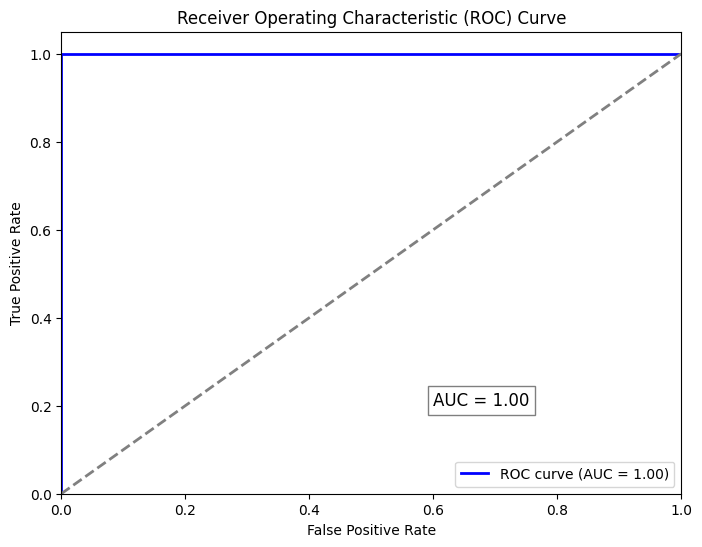

In [ ]:
#5.NB
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Load confusion matrix from the image (manually extracted key values)
# The confusion matrix is assumed to be square with labels on both axes

# Extracted matrix from the image (simplified version)
conf_matrix = np.array([
    [233, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 224, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 233, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 105, 0, 21, 0, 0, 0, 0, 6, 2, 4, 0, 1, 4, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 44, 0, 7, 1, 0, 5, 0],
    [0, 0, 0, 0, 212, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 0, 3, 0, 1, 65, 1, 0, 0, 2, 0, 1, 6, 1, 4, 29, 13, 0, 7, 0, 0, 2, 14, 0, 1, 13, 2, 3, 0, 6, 1, 0, 15, 0, 4, 0, 0, 0, 0, 7],
    [0, 0, 0, 0, 0, 0, 211, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 235, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 2, 0, 209, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 221, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 179, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 10, 0, 0, 1, 0, 0, 0, 0, 8, 0, 0],
    [0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 182, 0, 4, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 5, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 8, 0, 0, 0, 0, 187, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 1, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 238, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 3, 0, 0, 6, 0, 0, 0, 0, 7, 0, 12, 0, 135, 6, 5, 2, 0, 9, 2, 11, 0, 0, 1, 0, 0, 0, 0, 4, 0, 0, 0, 5, 0, 3, 0, 0, 7, 2],
    [1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 16, 0, 22, 0, 0, 143, 0, 0, 1, 0, 0, 0, 0, 0, 0, 17, 0, 0, 0, 3, 0, 0, 0, 0, 0, 23, 2, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 4, 0, 0, 1, 0, 0, 217, 0, 0, 0, 1, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 229, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 32, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 170, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 221, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 219, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 6, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 206, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 2, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 1, 0, 95, 19, 0, 1, 1, 0, 0, 0, 12, 0, 7, 60, 0, 6, 12, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 206, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 13, 0, 3, 0, 0, 2, 6, 0, 0, 8, 0, 0, 0, 0, 189, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 5, 0, 0, 0, 0],
    [4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 227, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 1, 198, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 0, 0, 0, 0, 18, 0, 0, 0, 0, 5, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 23, 0, 0, 0, 129, 4, 0, 1, 9, 0, 36, 0, 4, 0, 0, 2, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 223, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 6, 0, 0, 0, 190, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 213, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 236, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 227, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 4, 0, 0, 0, 0, 10, 7, 0, 16, 0, 0, 1, 7, 1, 9, 6, 0, 162, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 231, 0, 0, 0, 0, 0],
    [1, 0, 0, 0, 1, 0, 0, 0, 3, 13, 0, 0, 0, 5, 0, 1, 13, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 8, 1, 0, 0, 183, 2, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 215, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 220, 0, 0],
    [0, 0, 1, 39, 0, 0, 3, 2, 1, 0, 0, 15, 1, 2, 27, 0, 4, 0, 0, 5, 0, 14, 0, 21, 22, 0, 9, 34, 2, 2, 0, 7, 0, 1, 0, 0, 0, 0, 10, 20],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 4, 0, 6, 0, 0, 1, 0, 0, 0, 3, 4, 7, 0, 0, 2, 0, 0, 0, 1, 6, 0, 0, 0, 1, 0, 14, 0, 0, 0, 175]
])


# Create true labels from the confusion matrix
true_labels = np.repeat(np.arange(conf_matrix.shape[0]), conf_matrix.sum(axis=1))

# Create predicted labels based on the confusion matrix
predicted_labels = np.array([i for i in range(conf_matrix.shape[0]) for _ in range(conf_matrix[i, :].sum())])

# Binarize the true and predicted labels
y_true_bin = label_binarize(true_labels, classes=np.arange(conf_matrix.shape[0]))
y_pred_bin = label_binarize(predicted_labels, classes=np.arange(conf_matrix.shape[0]))

# Calculate ROC curve and AUC (model-level, One-vs-Rest)
fpr, tpr, thresholds = roc_curve(y_true_bin.ravel(), y_pred_bin.ravel())
roc_auc = auc(fpr, tpr)

# Print the model's ROC and AUC values
print("Model's ROC curve values:")
print(f"FPR (False Positive Rate): {fpr}")
print(f"TPR (True Positive Rate): {tpr}")
print(f"Thresholds: {thresholds}")

# Print the AUC value
print(f"Model's AUC: {roc_auc:.2f}")

# Plot the ROC curve for the model
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')

# Plot a diagonal line for the random classifier
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

# Customize the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')

# Add AUC value text inside the plot area
plt.text(0.6, 0.2, f'AUC = {roc_auc:.2f}', color='black', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

# Display the plot
plt.legend(loc='lower right')
plt.show()

Model's ROC curve values:
FPR (False Positive Rate): [0. 0. 1.]
TPR (True Positive Rate): [0. 1. 1.]
Thresholds: [inf  1.  0.]
Model's AUC: 1.00


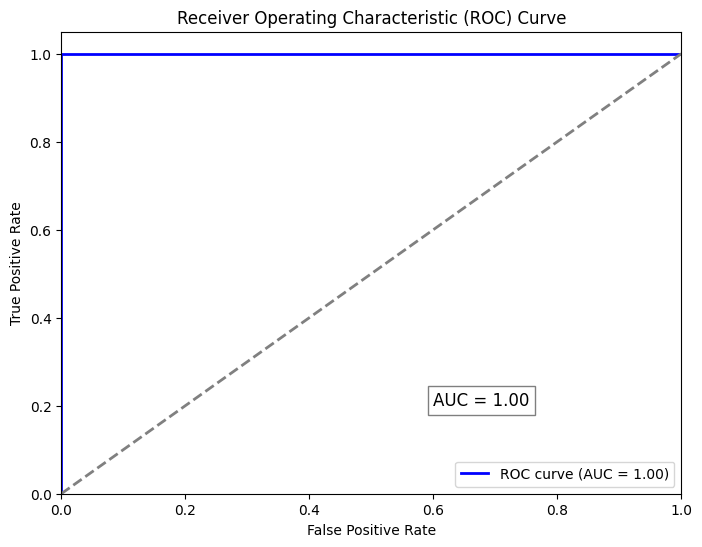

In [ ]:
#6.DT
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Load confusion matrix from the image (manually extracted key values)
# The confusion matrix is assumed to be square with labels on both axes

# Extracted matrix from the image (simplified version)
conf_matrix = np.array([
    [229, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 224, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 227, 0, 0, 2, 3, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 100, 0, 10, 0, 0, 0, 0, 5, 4, 6, 0, 7, 4, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 2, 0, 3, 0, 0, 0, 33, 0, 5, 0, 0, 18, 1],
    [0, 0, 0, 0, 200, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 11, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 3, 21, 1, 33, 1, 0, 0, 1, 0, 6, 11, 1, 7, 30, 8, 0, 8, 0, 1, 4, 16, 0, 1, 8, 3, 10, 0, 5, 0, 1, 12, 0, 3, 2, 0, 0, 0, 5],
    [0, 0, 1, 0, 0, 0, 198, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 3, 1],
    [0, 0, 0, 0, 0, 1, 0, 220, 0, 0, 0, 0, 9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 204, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 5, 0, 0, 0, 208, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 8, 0, 0, 0, 0],
    [0, 0, 4, 12, 0, 0, 0, 0, 0, 0, 138, 1, 1, 0, 5, 12, 2, 0, 0, 0, 0, 3, 0, 0, 2, 0, 0, 5, 0, 4, 2, 0, 2, 0, 0, 0, 0, 7, 0, 1],
    [0, 0, 0, 1, 0, 4, 1, 1, 0, 0, 3, 168, 0, 2, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 11, 0],
    [0, 0, 0, 3, 0, 18, 0, 5, 0, 0, 1, 0, 149, 0, 2, 11, 2, 0, 0, 0, 0, 0, 2, 0, 1, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 232, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0],
    [0, 0, 2, 2, 0, 8, 0, 0, 0, 0, 3, 1, 1, 0, 156, 1, 0, 0, 0, 0, 2, 2, 0, 0, 15, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 21, 4],
    [1, 0, 0, 4, 0, 68, 0, 0, 0, 0, 11, 1, 16, 0, 1, 76, 0, 0, 0, 0, 0, 0, 0, 0, 0, 15, 0, 1, 0, 4, 0, 0, 0, 1, 0, 29, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 9, 1, 0, 0, 0, 4, 0, 2, 2, 0, 6, 179, 0, 0, 0, 0, 1, 1, 0, 6, 2, 0, 3, 0, 1, 0, 0, 0, 3, 0, 6, 0, 0, 3, 1],
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 228, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 27, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 171, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 221, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 4, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 207, 1, 3, 0, 0, 0, 7, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 1, 0, 1, 0, 7, 0, 0, 0, 0, 4, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 181, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 8, 0, 1, 0, 0, 10, 2],
    [0, 0, 0, 2, 1, 23, 0, 0, 0, 0, 2, 0, 1, 0, 1, 3, 1, 0, 1, 0, 1, 0, 98, 12, 1, 0, 1, 14, 0, 0, 10, 0, 7, 25, 0, 4, 10, 0, 2, 0],
    [0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 6, 170, 0, 0, 0, 14, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 9, 0],
    [0, 0, 0, 1, 0, 6, 0, 0, 0, 0, 4, 0, 0, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 0, 193, 0, 0, 0, 1, 0, 0, 0, 0, 9, 0, 1, 0, 0, 13, 1],
    [0, 0, 0, 5, 0, 8, 0, 0, 0, 0, 0, 3, 0, 0, 1, 13, 1, 0, 0, 0, 0, 0, 0, 0, 1, 191, 0, 0, 0, 5, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0],
    [0, 0, 0, 3, 0, 1, 4, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 6, 0, 3, 1, 0, 1, 181, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 1],
    [0, 0, 0, 0, 3, 7, 0, 0, 0, 0, 5, 0, 0, 0, 0, 1, 0, 0, 2, 0, 3, 0, 13, 27, 0, 2, 0, 101, 0, 0, 2, 7, 0, 18, 0, 4, 0, 0, 36, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 3, 0, 2, 0, 0, 5, 210, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 4, 0, 13, 0, 0, 0, 0, 5, 1, 1, 0, 3, 4, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 167, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 10, 0, 0, 0, 0, 9, 0, 0, 188, 0, 0, 5, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 10, 0, 1, 0, 216, 0, 3, 0, 2, 0, 0, 2, 0],
    [0, 0, 0, 0, 0, 22, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 198, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 25, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 7, 0, 4, 1, 0, 0, 0, 10, 41, 1, 11, 0, 0, 19, 6, 1, 6, 7, 0, 83, 0, 0, 0, 0, 1, 1],
    [0, 0, 0, 0, 0, 13, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 217, 0, 0, 0, 0, 0],
    [2, 0, 0, 10, 1, 8, 0, 0, 6, 10, 0, 1, 0, 9, 2, 12, 17, 0, 0, 0, 0, 4, 2, 0, 3, 1, 0, 3, 0, 0, 0, 5, 0, 0, 1, 123, 2, 0, 0, 11],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 205, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 13, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 206, 0, 0],
    [0, 0, 0, 45, 0, 0, 3, 2, 1, 0, 0, 15, 1, 2, 35, 0, 4, 0, 0, 0, 0, 13, 5, 18, 29, 0, 9, 28, 2, 1, 0, 5, 0, 0, 0, 0, 0, 0, 5, 19],
    [0, 0, 0, 3, 0, 4, 0, 0, 0, 0, 1, 0, 3, 0, 3, 1, 3, 0, 0, 1, 4, 3, 0, 2, 5, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 4, 0, 0, 27, 159]
])


# Create true labels from the confusion matrix
true_labels = np.repeat(np.arange(conf_matrix.shape[0]), conf_matrix.sum(axis=1))

# Create predicted labels based on the confusion matrix
predicted_labels = np.array([i for i in range(conf_matrix.shape[0]) for _ in range(conf_matrix[i, :].sum())])

# Binarize the true and predicted labels
y_true_bin = label_binarize(true_labels, classes=np.arange(conf_matrix.shape[0]))
y_pred_bin = label_binarize(predicted_labels, classes=np.arange(conf_matrix.shape[0]))

# Calculate ROC curve and AUC (model-level, One-vs-Rest)
fpr, tpr, thresholds = roc_curve(y_true_bin.ravel(), y_pred_bin.ravel())
roc_auc = auc(fpr, tpr)

# Print the model's ROC and AUC values
print("Model's ROC curve values:")
print(f"FPR (False Positive Rate): {fpr}")
print(f"TPR (True Positive Rate): {tpr}")
print(f"Thresholds: {thresholds}")

# Print the AUC value
print(f"Model's AUC: {roc_auc:.2f}")

# Plot the ROC curve for the model
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')

# Plot a diagonal line for the random classifier
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

# Customize the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')

# Add AUC value text inside the plot area
plt.text(0.6, 0.2, f'AUC = {roc_auc:.2f}', color='black', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

# Display the plot
plt.legend(loc='lower right')
plt.show()

Model's ROC curve values:
FPR (False Positive Rate): [0. 0. 1.]
TPR (True Positive Rate): [0. 1. 1.]
Thresholds: [inf  1.  0.]
Model's AUC: 1.00


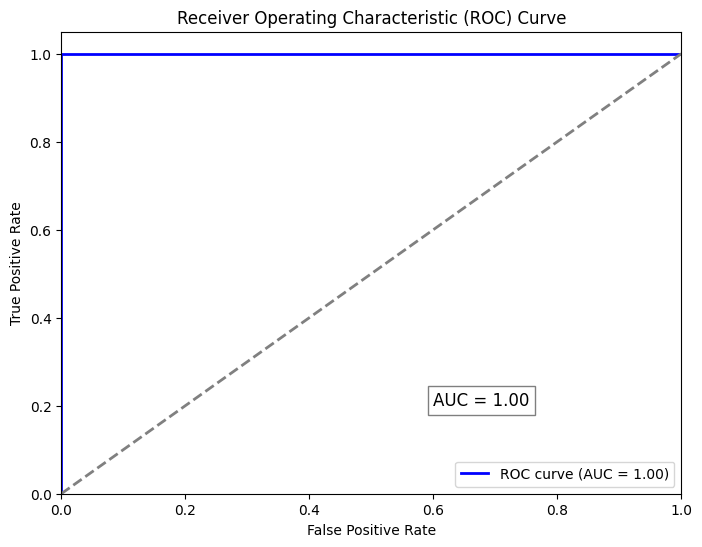

In [ ]:
#7.BERT
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Load confusion matrix from the image (manually extracted key values)
# The confusion matrix is assumed to be square with labels on both axes

# Extracted matrix from the image (simplified version)
conf_matrix = np.array([
    [229, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 220, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 219, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1],
    [1, 0, 2, 36, 0, 10, 2, 0, 1, 1, 6, 2, 3, 0, 7, 2, 1, 1, 1, 2, 2, 7, 2, 7, 3, 2, 5, 5, 5, 6, 0, 1, 4, 30, 1, 9, 5, 0, 21, 12],
    [0, 2, 0, 0, 161, 2, 0, 0, 2, 0, 0, 0, 1, 0, 0, 1, 0, 0, 8, 0, 6, 1, 0, 0, 0, 5, 0, 5, 14, 1, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0],
    [1, 0, 5, 8, 1, 40, 1, 1, 2, 2, 4, 3, 4, 2, 4, 17, 10, 0, 4, 0, 2, 4, 9, 0, 2, 6, 4, 3, 0, 12, 2, 1, 20, 3, 2, 15, 1, 0, 0, 7],
    [0, 0, 1, 0, 0, 0, 164, 2, 13, 0, 1, 6, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 4, 2, 0, 2, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 4],
    [0, 0, 0, 0, 0, 1, 6, 160, 1, 0, 0, 6, 7, 0, 3, 0, 2, 1, 1, 0, 1, 0, 0, 11, 3, 0, 3, 8, 0, 0, 0, 4, 0, 1, 0, 0, 0, 0, 4, 12],
    [0, 0, 0, 0, 0, 1, 3, 0, 187, 0, 1, 0, 0, 1, 0, 1, 2, 0, 1, 0, 0, 1, 0, 0, 2, 0, 0, 2, 0, 1, 1, 2, 0, 1, 0, 1, 0, 0, 1, 2],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 220, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 8, 0, 0, 0, 0, 0, 0, 111, 2, 4, 0, 5, 8, 5, 0, 0, 0, 0, 12, 2, 0, 2, 0, 1, 5, 3, 3, 1, 4, 3, 4, 0, 1, 0, 7, 0, 9],
    [2, 0, 2, 4, 1, 1, 10, 6, 0, 0, 1, 83, 0, 3, 9, 3, 7, 0, 0, 0, 0, 3, 0, 4, 2, 3, 5, 4, 2, 4, 0, 1, 0, 4, 0, 0, 1, 1, 15, 18],
    [2, 0, 0, 5, 0, 15, 0, 3, 6, 0, 4, 0, 103, 0, 5, 18, 1, 0, 0, 0, 4, 3, 3, 0, 2, 0, 1, 1, 1, 9, 0, 5, 2, 0, 0, 0, 2, 1, 0, 3],
    [0, 0, 0, 0, 0, 0, 3, 1, 0, 0, 0, 4, 0, 198, 2, 1, 3, 0, 0, 0, 0, 2, 0, 1, 2, 0, 2, 0, 0, 3, 0, 0, 0, 0, 0, 5, 1, 0, 4, 6],
    [0, 0, 3, 8, 0, 4, 2, 1, 2, 0, 7, 9, 4, 0, 56, 4, 1, 0, 0, 1, 3, 7, 1, 5, 7, 0, 6, 10, 9, 1, 2, 1, 3, 5, 1, 2, 3, 0, 29, 23],
    [3, 0, 1, 2, 2, 35, 1, 1, 7, 2, 10, 3, 22, 3, 12, 43, 1, 0, 1, 0, 1, 8, 1, 0, 0, 6, 3, 3, 1, 4, 0, 1, 3, 0, 0, 33, 5, 0, 0, 10],
    [0, 0, 0, 2, 0, 3, 1, 0, 3, 0, 4, 5, 2, 10, 11, 4, 88, 0, 0, 0, 0, 3, 12, 7, 6, 0, 4, 8, 4, 3, 0, 4, 3, 3, 2, 9, 1, 0, 6, 23],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 225, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0],
    [0, 0, 0, 0, 8, 4, 0, 0, 2, 0, 0, 0, 0, 0, 0, 3, 0, 0, 169, 0, 5, 0, 1, 0, 0, 0, 1, 0, 0, 2, 1, 0, 1, 0, 1, 1, 1, 0, 0, 2],
    [0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 205, 0, 0, 0, 1, 0, 0, 0, 1, 2, 0, 0, 0, 0, 4, 0, 0, 2, 0, 0, 0],
    [0, 0, 2, 0, 8, 0, 0, 2, 0, 0, 0, 1, 2, 0, 1, 0, 0, 0, 3, 0, 192, 0, 4, 0, 0, 0, 3, 0, 3, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1],
    [0, 0, 0, 8, 0, 1, 3, 2, 0, 0, 4, 6, 2, 2, 8, 0, 2, 1, 0, 1, 0, 114, 0, 8, 8, 0, 2, 0, 1, 1, 1, 7, 4, 7, 0, 2, 2, 0, 2, 22],
    [1, 0, 1, 2, 0, 14, 2, 1, 0, 0, 0, 1, 0, 0, 4, 4, 1, 0, 3, 1, 1, 3, 76, 12, 0, 1, 5, 6, 3, 3, 12, 1, 13, 30, 1, 4, 9, 0, 0, 5],
    [0, 0, 1, 2, 0, 0, 6, 0, 3, 0, 0, 10, 0, 1, 6, 0, 1, 0, 1, 0, 0, 1, 2, 136, 5, 0, 3, 7, 2, 0, 0, 0, 0, 1, 0, 3, 1, 0, 6, 8],
    [0, 0, 0, 3, 0, 3, 6, 1, 9, 0, 6, 15, 1, 0, 9, 4, 7, 1, 0, 0, 1, 6, 2, 10, 74, 2, 10, 3, 3, 3, 0, 5, 2, 10, 0, 2, 0, 0, 17, 17],
    [1, 0, 0, 7, 0, 8, 0, 0, 0, 0, 6, 5, 0, 3, 4, 20, 0, 1, 0, 0, 0, 3, 2, 1, 0, 128, 5, 3, 6, 5, 0, 1, 0, 10, 0, 2, 7, 0, 1, 2],
    [0, 0, 0, 2, 0, 1, 17, 2, 3, 0, 0, 6, 0, 1, 5, 1, 3, 0, 0, 0, 20, 1, 1, 3, 3, 0, 102, 3, 2, 1, 0, 0, 0, 0, 0, 6, 4, 1, 6, 14],
    [0, 0, 1, 0, 4, 8, 3, 1, 5, 0, 5, 2, 2, 1, 7, 4, 3, 0, 3, 0, 2, 3, 12, 32, 7, 2, 6, 39, 9, 7, 4, 8, 0, 13, 2, 6, 0, 0, 24, 10],
    [0, 0, 0, 2, 1, 0, 0, 0, 1, 0, 1, 6, 0, 2, 12, 0, 4, 0, 2, 0, 1, 3, 1, 8, 2, 5, 4, 3, 149, 0, 0, 0, 0, 3, 0, 0, 1, 0, 2, 10],
    [0, 0, 1, 2, 0, 8, 1, 0, 8, 0, 4, 4, 3, 0, 1, 10, 2, 0, 1, 0, 1, 3, 1, 0, 2, 0, 0, 2, 0, 125, 1, 0, 1, 1, 1, 6, 5, 1, 1, 5],
    [0, 0, 0, 1, 0, 0, 0, 0, 3, 0, 2, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 3, 0, 1, 185, 0, 3, 2, 0, 1, 2, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 3, 7, 2, 0, 0, 1, 3, 0, 0, 2, 4, 0, 2, 0, 1, 0, 2, 0, 2, 0, 15, 9, 0, 2, 1, 153, 1, 0, 3, 14, 1, 0, 1, 5],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 150, 1, 0, 3, 0, 1, 0, 1],
    [1, 0, 1, 11, 0, 0, 1, 0, 1, 0, 0, 3, 1, 1, 8, 5, 5, 0, 0, 0, 1, 3, 47, 0, 9, 1, 2, 14, 10, 5, 5, 6, 1, 70, 1, 3, 2, 0, 1, 7],
    [0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 216, 4, 1, 0, 0, 0],
    [1, 0, 2, 4, 1, 5, 0, 0, 12, 30, 3, 1, 2, 2, 2, 19, 11, 1, 0, 0, 4, 1, 2, 1, 4, 2, 1, 2, 0, 4, 0, 4, 1, 0, 1, 95, 2, 0, 0, 14],
    [0, 0, 0, 3, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 2, 0, 0, 0, 0, 1, 2, 0, 0, 0, 2, 0, 0, 3, 195, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 215, 0, 0],
    [0, 0, 0, 17, 0, 0, 0, 1, 2, 0, 0, 3, 0, 1, 2, 0, 0, 0, 0, 0, 0, 11, 0, 19, 16, 0, 2, 28, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 132, 5],
    [0, 0, 0, 3, 0, 3, 7, 1, 3, 0, 3, 11, 4, 1, 11, 1, 4, 0, 2, 1, 3, 4, 2, 6, 6, 2, 2, 3, 5, 7, 0, 0, 2, 1, 0, 9, 1, 0, 21, 96]
])


# Create true labels from the confusion matrix
true_labels = np.repeat(np.arange(conf_matrix.shape[0]), conf_matrix.sum(axis=1))

# Create predicted labels based on the confusion matrix
predicted_labels = np.array([i for i in range(conf_matrix.shape[0]) for _ in range(conf_matrix[i, :].sum())])

# Binarize the true and predicted labels
y_true_bin = label_binarize(true_labels, classes=np.arange(conf_matrix.shape[0]))
y_pred_bin = label_binarize(predicted_labels, classes=np.arange(conf_matrix.shape[0]))

# Calculate ROC curve and AUC (model-level, One-vs-Rest)
fpr, tpr, thresholds = roc_curve(y_true_bin.ravel(), y_pred_bin.ravel())
roc_auc = auc(fpr, tpr)

# Print the model's ROC and AUC values
print("Model's ROC curve values:")
print(f"FPR (False Positive Rate): {fpr}")
print(f"TPR (True Positive Rate): {tpr}")
print(f"Thresholds: {thresholds}")

# Print the AUC value
print(f"Model's AUC: {roc_auc:.2f}")

# Plot the ROC curve for the model
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')

# Plot a diagonal line for the random classifier
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

# Customize the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')

# Add AUC value text inside the plot area
plt.text(0.6, 0.2, f'AUC = {roc_auc:.2f}', color='black', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

# Display the plot
plt.legend(loc='lower right')
plt.show()

In [ ]:
#8.BIOBERT
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Load confusion matrix from the image (manually extracted key values)
# The confusion matrix is assumed to be square with labels on both axes

# Extracted matrix from the image (simplified version)
conf_matrix = np.array([
    [229, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 220, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 219, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1],
    [1, 0, 2, 36, 0, 10, 2, 0, 1, 1, 6, 2, 3, 0, 7, 2, 1, 1, 1, 2, 2, 7, 2, 7, 3, 2, 5, 5, 5, 6, 0, 1, 4, 30, 1, 9, 5, 0, 21, 12],
    [0, 2, 0, 0, 161, 2, 0, 0, 2, 0, 0, 0, 1, 0, 0, 1, 0, 0, 8, 0, 6, 1, 0, 0, 0, 5, 0, 5, 14, 1, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0],
    [1, 0, 5, 8, 1, 40, 1, 1, 2, 2, 4, 3, 4, 2, 4, 17, 10, 0, 4, 0, 2, 4, 9, 0, 2, 6, 4, 3, 0, 12, 2, 1, 20, 3, 2, 15, 1, 0, 0, 7],
    [0, 0, 1, 0, 0, 0, 164, 2, 13, 0, 1, 6, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 4, 2, 0, 2, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 4],
    [0, 0, 0, 0, 0, 1, 6, 160, 1, 0, 0, 6, 7, 0, 3, 0, 2, 1, 1, 0, 1, 0, 0, 11, 3, 0, 3, 8, 0, 0, 0, 4, 0, 1, 0, 0, 0, 0, 4, 12],
    [0, 0, 0, 0, 0, 1, 3, 0, 187, 0, 1, 0, 0, 1, 0, 1, 2, 0, 1, 0, 0, 1, 0, 0, 2, 0, 0, 2, 0, 1, 1, 2, 0, 1, 0, 1, 0, 0, 1, 2],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 220, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 8, 0, 0, 0, 0, 0, 0, 111, 2, 4, 0, 5, 8, 5, 0, 0, 0, 0, 12, 2, 0, 2, 0, 1, 5, 3, 3, 1, 4, 3, 4, 0, 1, 0, 7, 0, 9],
    [2, 0, 2, 4, 1, 1, 10, 6, 0, 0, 1, 83, 0, 3, 9, 3, 7, 0, 0, 0, 0, 3, 0, 4, 2, 3, 5, 4, 2, 4, 0, 1, 0, 4, 0, 0, 1, 1, 15, 18],
    [2, 0, 0, 5, 0, 15, 0, 3, 6, 0, 4, 0, 103, 0, 5, 18, 1, 0, 0, 0, 4, 3, 3, 0, 2, 0, 1, 1, 1, 9, 0, 5, 2, 0, 0, 0, 2, 1, 0, 3],
    [0, 0, 0, 0, 0, 0, 3, 1, 0, 0, 0, 4, 0, 198, 2, 1, 3, 0, 0, 0, 0, 2, 0, 1, 2, 0, 2, 0, 0, 3, 0, 0, 0, 0, 0, 5, 1, 0, 4, 6],
    [0, 0, 3, 8, 0, 4, 2, 1, 2, 0, 7, 9, 4, 0, 56, 4, 1, 0, 0, 1, 3, 7, 1, 5, 7, 0, 6, 10, 9, 1, 2, 1, 3, 5, 1, 2, 3, 0, 29, 23],
    [3, 0, 1, 2, 2, 35, 1, 1, 7, 2, 10, 3, 22, 3, 12, 43, 1, 0, 1, 0, 1, 8, 1, 0, 0, 6, 3, 3, 1, 4, 0, 1, 3, 0, 0, 33, 5, 0, 0, 10],
    [0, 0, 0, 2, 0, 3, 1, 0, 3, 0, 4, 5, 2, 10, 11, 4, 88, 0, 0, 0, 0, 3, 12, 7, 6, 0, 4, 8, 4, 3, 0, 4, 3, 3, 2, 9, 1, 0, 6, 23],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 225, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0],
    [0, 0, 0, 0, 8, 4, 0, 0, 2, 0, 0, 0, 0, 0, 0, 3, 0, 0, 169, 0, 5, 0, 1, 0, 0, 0, 1, 0, 0, 2, 1, 0, 1, 0, 1, 1, 1, 0, 0, 2],
    [0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 205, 0, 0, 0, 1, 0, 0, 0, 1, 2, 0, 0, 0, 0, 4, 0, 0, 2, 0, 0, 0],
    [0, 0, 2, 0, 8, 0, 0, 2, 0, 0, 0, 1, 2, 0, 1, 0, 0, 0, 3, 0, 192, 0, 4, 0, 0, 0, 3, 0, 3, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1],
    [0, 0, 0, 8, 0, 1, 3, 2, 0, 0, 4, 6, 2, 2, 8, 0, 2, 1, 0, 1, 0, 114, 0, 8, 8, 0, 2, 0, 1, 1, 1, 7, 4, 7, 0, 2, 2, 0, 2, 22],
    [1, 0, 1, 2, 0, 14, 2, 1, 0, 0, 0, 1, 0, 0, 4, 4, 1, 0, 3, 1, 1, 3, 76, 12, 0, 1, 5, 6, 3, 3, 12, 1, 13, 30, 1, 4, 9, 0, 0, 5],
    [0, 0, 1, 2, 0, 0, 6, 0, 3, 0, 0, 10, 0, 1, 6, 0, 1, 0, 1, 0, 0, 1, 2, 136, 5, 0, 3, 7, 2, 0, 0, 0, 0, 1, 0, 3, 1, 0, 6, 8],
    [0, 0, 0, 3, 0, 3, 6, 1, 9, 0, 6, 15, 1, 0, 9, 4, 7, 1, 0, 0, 1, 6, 2, 10, 74, 2, 10, 3, 3, 3, 0, 5, 2, 10, 0, 2, 0, 0, 17, 17],
    [1, 0, 0, 7, 0, 8, 0, 0, 0, 0, 6, 5, 0, 3, 4, 20, 0, 1, 0, 0, 0, 3, 2, 1, 0, 128, 5, 3, 6, 5, 0, 1, 0, 10, 0, 2, 7, 0, 1, 2],
    [0, 0, 0, 2, 0, 1, 17, 2, 3, 0, 0, 6, 0, 1, 5, 1, 3, 0, 0, 0, 20, 1, 1, 3, 3, 0, 102, 3, 2, 1, 0, 0, 0, 0, 0, 6, 4, 1, 6, 14],
    [0, 0, 1, 0, 4, 8, 3, 1, 5, 0, 5, 2, 2, 1, 7, 4, 3, 0, 3, 0, 2, 3, 12, 32, 7, 2, 6, 39, 9, 7, 4, 8, 0, 13, 2, 6, 0, 0, 24, 10],
    [0, 0, 0, 2, 1, 0, 0, 0, 1, 0, 1, 6, 0, 2, 12, 0, 4, 0, 2, 0, 1, 3, 1, 8, 2, 5, 4, 3, 149, 0, 0, 0, 0, 3, 0, 0, 1, 0, 2, 10],
    [0, 0, 1, 2, 0, 8, 1, 0, 8, 0, 4, 4, 3, 0, 1, 10, 2, 0, 1, 0, 1, 3, 1, 0, 2, 0, 0, 2, 0, 125, 1, 0, 1, 1, 1, 6, 5, 1, 1, 5],
    [0, 0, 0, 1, 0, 0, 0, 0, 3, 0, 2, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 3, 0, 1, 185, 0, 3, 2, 0, 1, 2, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 3, 7, 2, 0, 0, 1, 3, 0, 0, 2, 4, 0, 2, 0, 1, 0, 2, 0, 2, 0, 15, 9, 0, 2, 1, 153, 1, 0, 3, 14, 1, 0, 1, 5],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 150, 1, 0, 3, 0, 1, 0, 1],
    [1, 0, 1, 11, 0, 0, 1, 0, 1, 0, 0, 3, 1, 1, 8, 5, 5, 0, 0, 0, 1, 3, 47, 0, 9, 1, 2, 14, 10, 5, 5, 6, 1, 70, 1, 3, 2, 0, 1, 7],
    [0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 216, 4, 1, 0, 0, 0],
    [1, 0, 2, 4, 1, 5, 0, 0, 12, 30, 3, 1, 2, 2, 2, 19, 11, 1, 0, 0, 4, 1, 2, 1, 4, 2, 1, 2, 0, 4, 0, 4, 1, 0, 1, 95, 2, 0, 0, 14],
    [0, 0, 0, 3, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 2, 0, 0, 0, 0, 1, 2, 0, 0, 0, 2, 0, 0, 3, 195, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 215, 0, 0],
    [0, 0, 0, 17, 0, 0, 0, 1, 2, 0, 0, 3, 0, 1, 2, 0, 0, 0, 0, 0, 0, 11, 0, 19, 16, 0, 2, 28, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 132, 5],
    [0, 0, 0, 3, 0, 3, 7, 1, 3, 0, 3, 11, 4, 1, 11, 1, 4, 0, 2, 1, 3, 4, 2, 6, 6, 2, 2, 3, 5, 7, 0, 0, 2, 1, 0, 9, 1, 0, 21, 96]
])


# Create true labels from the confusion matrix
true_labels = np.repeat(np.arange(conf_matrix.shape[0]), conf_matrix.sum(axis=1))

# Create predicted labels based on the confusion matrix
predicted_labels = np.array([i for i in range(conf_matrix.shape[0]) for _ in range(conf_matrix[i, :].sum())])

# Binarize the true and predicted labels
y_true_bin = label_binarize(true_labels, classes=np.arange(conf_matrix.shape[0]))
y_pred_bin = label_binarize(predicted_labels, classes=np.arange(conf_matrix.shape[0]))

# Calculate ROC curve and AUC (model-level, One-vs-Rest)
fpr, tpr, thresholds = roc_curve(y_true_bin.ravel(), y_pred_bin.ravel())
roc_auc = auc(fpr, tpr)

# Print the model's ROC and AUC values
print("Model's ROC curve values:")
print(f"FPR (False Positive Rate): {fpr}")
print(f"TPR (True Positive Rate): {tpr}")
print(f"Thresholds: {thresholds}")

# Print the AUC value
print(f"Model's AUC: {roc_auc:.2f}")

# Plot the ROC curve for the model
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')

# Plot a diagonal line for the random classifier
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

# Customize the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')

# Add AUC value text inside the plot area
plt.text(0.6, 0.2, f'AUC = {roc_auc:.2f}', color='black', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

# Display the plot
plt.legend(loc='lower right')
plt.show()

In [ ]:
#9. DISTILBERT
surgery_nb = [0, 0, 1, 39, 0, 0, 3, 2, 1, 0,
              0, 15, 1, 2, 27, 0, 4, 0, 0, 5,
              0, 14, 0, 21, 22, 0, 9, 34, 2, 2,
              0, 7, 0, 1, 0, 0, 0, 0, 10, 20]

surgery_distilbert = [0, 0, 0, 37, 0, 0, 0, 0, 1, 0,
                      0, 5, 0, 1, 14, 0, 1, 0, 0, 0,
                      0, 9, 0, 22, 0, 0, 0, 0, 2, 0,
                      0, 3, 0, 0, 0, 0, 0, 0, 147, 0]

# ROC IRIS

In [ ]:
! pip install --upgrade scikit-learn
! pip install --upgrade matplotlib


In [1]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
target_names = iris.target_names
X, y = iris.data, iris.target
y = iris.target_names[y]

## Add noisy features to make the problem harder
random_state = np.random.RandomState(0)
n_samples, n_features = X.shape
n_classes = len(np.unique(y))
X = np.concatenate([X, random_state.randn(n_samples, 200 * n_features)], axis=1)

## Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y, random_state=0)

In [3]:
print(X_train)
print(type(X_train))

[[ 5.4         3.9         1.3        ... -0.46397796 -1.52208557
   0.23352742]
 [ 5.6         2.5         3.9        ... -0.03157472  0.30253713
   0.47783207]
 [ 5.7         4.4         1.5        ... -0.03818131 -0.61738596
   0.37894461]
 ...
 [ 6.5         3.          5.8        ... -0.66241674  0.22992842
  -0.39345333]
 [ 5.8         2.7         3.9        ...  1.22536528 -0.83526295
  -0.43997469]
 [ 4.9         3.1         1.5        ...  0.4666787  -1.90542325
  -0.33794381]]
<class 'numpy.ndarray'>


In [4]:
print(X_test)
print(type(X_test))

[[ 6.9         3.1         5.4        ... -2.02833157  0.57514494
  -0.61323723]
 [ 6.7         3.1         4.4        ... -0.20173394  0.05877876
  -0.84869703]
 [ 6.7         3.          5.2        ... -0.55450646 -1.49468645
  -0.96512599]
 ...
 [ 6.9         3.2         5.7        ... -0.75381197  1.52011091
  -0.7561061 ]
 [ 5.1         3.8         1.6        ... -0.05454311 -1.54549223
  -1.67568201]
 [ 5.7         2.8         4.5        ...  2.14234669  0.85097102
  -0.34667899]]
<class 'numpy.ndarray'>


In [5]:
print(y_train)
print(type(y_train))

['setosa' 'versicolor' 'setosa' 'setosa' 'versicolor' 'virginica'
 'virginica' 'setosa' 'versicolor' 'setosa' 'versicolor' 'versicolor'
 'virginica' 'setosa' 'versicolor' 'setosa' 'virginica' 'setosa'
 'versicolor' 'versicolor' 'versicolor' 'setosa' 'virginica' 'versicolor'
 'versicolor' 'virginica' 'versicolor' 'versicolor' 'setosa' 'virginica'
 'setosa' 'versicolor' 'virginica' 'virginica' 'versicolor' 'setosa'
 'setosa' 'virginica' 'setosa' 'virginica' 'versicolor' 'virginica'
 'setosa' 'versicolor' 'versicolor' 'virginica' 'versicolor' 'virginica'
 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor' 'setosa'
 'setosa' 'virginica' 'virginica' 'virginica' 'virginica' 'setosa'
 'virginica' 'setosa' 'versicolor' 'setosa' 'setosa' 'setosa' 'virginica'
 'virginica' 'virginica' 'virginica' 'versicolor' 'setosa' 'virginica'
 'versicolor' 'setosa']
<class 'numpy.ndarray'>


In [6]:
print(y_test)
print(type(y_test))

['virginica' 'versicolor' 'virginica' 'setosa' 'virginica' 'setosa'
 'versicolor' 'setosa' 'virginica' 'versicolor' 'setosa' 'virginica'
 'versicolor' 'setosa' 'versicolor' 'setosa' 'virginica' 'virginica'
 'setosa' 'setosa' 'versicolor' 'setosa' 'virginica' 'virginica'
 'virginica' 'virginica' 'virginica' 'setosa' 'virginica' 'versicolor'
 'virginica' 'virginica' 'versicolor' 'virginica' 'setosa' 'setosa'
 'setosa' 'setosa' 'versicolor' 'versicolor' 'setosa' 'setosa'
 'versicolor' 'versicolor' 'setosa' 'virginica' 'setosa' 'versicolor'
 'versicolor' 'virginica' 'versicolor' 'setosa' 'virginica' 'setosa'
 'versicolor' 'versicolor' 'setosa' 'virginica' 'versicolor' 'virginica'
 'versicolor' 'virginica' 'versicolor' 'virginica' 'setosa' 'setosa'
 'versicolor' 'setosa' 'versicolor' 'versicolor' 'virginica' 'versicolor'
 'virginica' 'setosa' 'versicolor']
<class 'numpy.ndarray'>


In [7]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

## Binarize the target using the OvR strategy
label_binarizer = LabelBinarizer().fit(y_train)
y_onehot_val = label_binarizer.transform(y_test)

In [8]:
print(label_binarizer)
print(type(label_binarizer))

LabelBinarizer()
<class 'sklearn.preprocessing._label.LabelBinarizer'>


In [9]:
print(y_onehot_val)
print(type(y_onehot_val))

[[0 0 1]
 [0 1 0]
 [0 0 1]
 [1 0 0]
 [0 0 1]
 [1 0 0]
 [0 1 0]
 [1 0 0]
 [0 0 1]
 [0 1 0]
 [1 0 0]
 [0 0 1]
 [0 1 0]
 [1 0 0]
 [0 1 0]
 [1 0 0]
 [0 0 1]
 [0 0 1]
 [1 0 0]
 [1 0 0]
 [0 1 0]
 [1 0 0]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [1 0 0]
 [0 0 1]
 [0 1 0]
 [0 0 1]
 [0 0 1]
 [0 1 0]
 [0 0 1]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [0 1 0]
 [0 1 0]
 [1 0 0]
 [1 0 0]
 [0 1 0]
 [0 1 0]
 [1 0 0]
 [0 0 1]
 [1 0 0]
 [0 1 0]
 [0 1 0]
 [0 0 1]
 [0 1 0]
 [1 0 0]
 [0 0 1]
 [1 0 0]
 [0 1 0]
 [0 1 0]
 [1 0 0]
 [0 0 1]
 [0 1 0]
 [0 0 1]
 [0 1 0]
 [0 0 1]
 [0 1 0]
 [0 0 1]
 [1 0 0]
 [1 0 0]
 [0 1 0]
 [1 0 0]
 [0 1 0]
 [0 1 0]
 [0 0 1]
 [0 1 0]
 [0 0 1]
 [1 0 0]
 [0 1 0]]
<class 'numpy.ndarray'>


In [10]:
## Train a Logistic Regression model
classifier = LogisticRegression()
y_score = classifier.fit(X_train, y_train).predict_proba(X_test)

In [11]:
print(classifier)
print(type(classifier))

LogisticRegression()
<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [12]:
print(y_score)
print(type(y_score))

[[0.38095776 0.05072909 0.56831315]
 [0.07031555 0.27915668 0.65052777]
 [0.32518843 0.0920671  0.58274447]
 [0.66083178 0.13605963 0.20310859]
 [0.09502454 0.1913814  0.71359406]
 [0.64647439 0.05039354 0.30313206]
 [0.1543094  0.29525714 0.55043345]
 [0.66859233 0.23292731 0.09848036]
 [0.01797098 0.26808171 0.71394731]
 [0.470709   0.14814238 0.38114862]
 [0.70272109 0.02149585 0.27578306]
 [0.62845106 0.0909246  0.28062433]
 [0.03402058 0.91136371 0.05461571]
 [0.8887887  0.07273617 0.03847513]
 [0.0325917  0.13058552 0.83682278]
 [0.78954536 0.09636036 0.11409427]
 [0.13225894 0.23406469 0.63367637]
 [0.54612789 0.21527602 0.2385961 ]
 [0.61594773 0.11086636 0.27318591]
 [0.71002407 0.14652079 0.14345514]
 [0.07669563 0.63436711 0.28893726]
 [0.77655538 0.08614687 0.13729774]
 [0.16391094 0.13953863 0.69655043]
 [0.22569153 0.09310927 0.6811992 ]
 [0.16455802 0.40156456 0.43387741]
 [0.06499602 0.56783934 0.36716464]
 [0.03616987 0.13514962 0.82868051]
 [0.44082009 0.49525559 0.06

In [13]:
## Calculate ROC curve and ROC AUC score for each class
fpr, tpr, roc_auc = dict(), dict(), dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_onehot_val[:, i], y_score[:, i])
    roc_auc[i] = roc_auc_score(y_onehot_val[:, i], y_score[:, i])

## Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_onehot_val.ravel(), y_score.ravel())
roc_auc["micro"] = roc_auc_score(y_onehot_val, y_score, multi_class="ovr", average="micro")

In [14]:
print(fpr)
print(type(fpr))

{0: array([0.  , 0.  , 0.  , 0.02, 0.02, 0.04, 0.04, 0.06, 0.06, 0.08, 0.08,
       0.14, 0.14, 0.22, 0.22, 0.24, 0.24, 0.38, 0.38, 0.68, 0.68, 0.72,
       0.72, 1.  ]), 1: array([0.  , 0.  , 0.  , 0.02, 0.02, 0.04, 0.04, 0.06, 0.06, 0.08, 0.08,
       0.1 , 0.1 , 0.12, 0.12, 0.16, 0.16, 0.18, 0.18, 0.2 , 0.2 , 0.24,
       0.24, 0.28, 0.28, 0.38, 0.38, 0.44, 0.44, 0.5 , 0.5 , 0.58, 0.58,
       0.84, 0.84, 0.86, 0.86, 0.88, 0.88, 0.92, 0.92, 1.  ]), 2: array([0.  , 0.02, 0.02, 0.06, 0.06, 0.08, 0.08, 0.1 , 0.1 , 0.12, 0.12,
       0.14, 0.14, 0.16, 0.16, 0.18, 0.18, 0.26, 0.26, 0.28, 0.28, 0.34,
       0.34, 0.38, 0.38, 0.4 , 0.4 , 0.44, 0.44, 0.72, 0.72, 0.74, 0.74,
       1.  ]), 'micro': array([0.        , 0.        , 0.        , 0.00666667, 0.00666667,
       0.01333333, 0.01333333, 0.02666667, 0.02666667, 0.03333333,
       0.03333333, 0.04      , 0.04      , 0.04666667, 0.04666667,
       0.05333333, 0.05333333, 0.06      , 0.06      , 0.06666667,
       0.06666667, 0.07333333,

In [15]:
print(tpr)
print(type(tpr))

{0: array([0.  , 0.04, 0.4 , 0.4 , 0.52, 0.52, 0.56, 0.56, 0.68, 0.68, 0.76,
       0.76, 0.8 , 0.8 , 0.84, 0.84, 0.88, 0.88, 0.92, 0.92, 0.96, 0.96,
       1.  , 1.  ]), 1: array([0.  , 0.04, 0.08, 0.08, 0.12, 0.12, 0.2 , 0.2 , 0.24, 0.24, 0.28,
       0.28, 0.32, 0.32, 0.36, 0.36, 0.4 , 0.4 , 0.44, 0.44, 0.48, 0.48,
       0.52, 0.52, 0.6 , 0.6 , 0.64, 0.64, 0.72, 0.72, 0.76, 0.76, 0.8 ,
       0.8 , 0.88, 0.88, 0.92, 0.92, 0.96, 0.96, 1.  , 1.  ]), 2: array([0.  , 0.  , 0.12, 0.12, 0.2 , 0.2 , 0.28, 0.28, 0.36, 0.36, 0.44,
       0.44, 0.52, 0.52, 0.56, 0.56, 0.6 , 0.6 , 0.68, 0.68, 0.76, 0.76,
       0.8 , 0.8 , 0.84, 0.84, 0.88, 0.88, 0.92, 0.92, 0.96, 0.96, 1.  ,
       1.  ]), 'micro': array([0.        , 0.01333333, 0.06666667, 0.06666667, 0.13333333,
       0.13333333, 0.14666667, 0.14666667, 0.18666667, 0.18666667,
       0.25333333, 0.25333333, 0.29333333, 0.29333333, 0.32      ,
       0.32      , 0.33333333, 0.33333333, 0.37333333, 0.37333333,
       0.38666667, 0.38666667,

In [16]:
print(roc_auc)
print(type(roc_auc))

{0: np.float64(0.8872), 1: np.float64(0.6607999999999999), 2: np.float64(0.78), 'micro': np.float64(0.7698666666666667)}
<class 'dict'>


In [17]:
## Compute macro-average ROC curve and ROC area
## Aggregate the true/false positive rates per class
fpr["macro"], tpr["macro"] = [], []
for i in range(n_classes):
    fpr_averaged, tpr_averaged = [], []
    for j in range(n_classes):
        if i != j:
            fpr_averaged += list(fpr[j])
            tpr_averaged += list(tpr[j])
    fpr_averaged = np.array(fpr_averaged)
    tpr_averaged = np.array(tpr_averaged)
    fpr["macro"].append(fpr_averaged)
    tpr["macro"].append(tpr_averaged)
fpr["macro"] = np.concatenate(fpr["macro"])
tpr["macro"] = np.concatenate(tpr["macro"])
roc_auc["macro"] = roc_auc_score(y_onehot_val, y_score, multi_class="ovr", average="macro")

In [18]:
print(fpr_averaged)
print(type(fpr_averaged))

[0.   0.   0.   0.02 0.02 0.04 0.04 0.06 0.06 0.08 0.08 0.14 0.14 0.22
 0.22 0.24 0.24 0.38 0.38 0.68 0.68 0.72 0.72 1.   0.   0.   0.   0.02
 0.02 0.04 0.04 0.06 0.06 0.08 0.08 0.1  0.1  0.12 0.12 0.16 0.16 0.18
 0.18 0.2  0.2  0.24 0.24 0.28 0.28 0.38 0.38 0.44 0.44 0.5  0.5  0.58
 0.58 0.84 0.84 0.86 0.86 0.88 0.88 0.92 0.92 1.  ]
<class 'numpy.ndarray'>


In [19]:
print(tpr_averaged)
print(type(tpr_averaged))

[0.   0.04 0.4  0.4  0.52 0.52 0.56 0.56 0.68 0.68 0.76 0.76 0.8  0.8
 0.84 0.84 0.88 0.88 0.92 0.92 0.96 0.96 1.   1.   0.   0.04 0.08 0.08
 0.12 0.12 0.2  0.2  0.24 0.24 0.28 0.28 0.32 0.32 0.36 0.36 0.4  0.4
 0.44 0.44 0.48 0.48 0.52 0.52 0.6  0.6  0.64 0.64 0.72 0.72 0.76 0.76
 0.8  0.8  0.88 0.88 0.92 0.92 0.96 0.96 1.   1.  ]
<class 'numpy.ndarray'>


In [20]:
print(fpr["macro"])
print(type(fpr["macro"]))

[0.   0.   0.   0.02 0.02 0.04 0.04 0.06 0.06 0.08 0.08 0.1  0.1  0.12
 0.12 0.16 0.16 0.18 0.18 0.2  0.2  0.24 0.24 0.28 0.28 0.38 0.38 0.44
 0.44 0.5  0.5  0.58 0.58 0.84 0.84 0.86 0.86 0.88 0.88 0.92 0.92 1.
 0.   0.02 0.02 0.06 0.06 0.08 0.08 0.1  0.1  0.12 0.12 0.14 0.14 0.16
 0.16 0.18 0.18 0.26 0.26 0.28 0.28 0.34 0.34 0.38 0.38 0.4  0.4  0.44
 0.44 0.72 0.72 0.74 0.74 1.   0.   0.   0.   0.02 0.02 0.04 0.04 0.06
 0.06 0.08 0.08 0.14 0.14 0.22 0.22 0.24 0.24 0.38 0.38 0.68 0.68 0.72
 0.72 1.   0.   0.02 0.02 0.06 0.06 0.08 0.08 0.1  0.1  0.12 0.12 0.14
 0.14 0.16 0.16 0.18 0.18 0.26 0.26 0.28 0.28 0.34 0.34 0.38 0.38 0.4
 0.4  0.44 0.44 0.72 0.72 0.74 0.74 1.   0.   0.   0.   0.02 0.02 0.04
 0.04 0.06 0.06 0.08 0.08 0.14 0.14 0.22 0.22 0.24 0.24 0.38 0.38 0.68
 0.68 0.72 0.72 1.   0.   0.   0.   0.02 0.02 0.04 0.04 0.06 0.06 0.08
 0.08 0.1  0.1  0.12 0.12 0.16 0.16 0.18 0.18 0.2  0.2  0.24 0.24 0.28
 0.28 0.38 0.38 0.44 0.44 0.5  0.5  0.58 0.58 0.84 0.84 0.86 0.86 0.88
 0.88 0.9

In [21]:
print(tpr["macro"])
print(type(tpr["macro"]))

[0.   0.04 0.08 0.08 0.12 0.12 0.2  0.2  0.24 0.24 0.28 0.28 0.32 0.32
 0.36 0.36 0.4  0.4  0.44 0.44 0.48 0.48 0.52 0.52 0.6  0.6  0.64 0.64
 0.72 0.72 0.76 0.76 0.8  0.8  0.88 0.88 0.92 0.92 0.96 0.96 1.   1.
 0.   0.   0.12 0.12 0.2  0.2  0.28 0.28 0.36 0.36 0.44 0.44 0.52 0.52
 0.56 0.56 0.6  0.6  0.68 0.68 0.76 0.76 0.8  0.8  0.84 0.84 0.88 0.88
 0.92 0.92 0.96 0.96 1.   1.   0.   0.04 0.4  0.4  0.52 0.52 0.56 0.56
 0.68 0.68 0.76 0.76 0.8  0.8  0.84 0.84 0.88 0.88 0.92 0.92 0.96 0.96
 1.   1.   0.   0.   0.12 0.12 0.2  0.2  0.28 0.28 0.36 0.36 0.44 0.44
 0.52 0.52 0.56 0.56 0.6  0.6  0.68 0.68 0.76 0.76 0.8  0.8  0.84 0.84
 0.88 0.88 0.92 0.92 0.96 0.96 1.   1.   0.   0.04 0.4  0.4  0.52 0.52
 0.56 0.56 0.68 0.68 0.76 0.76 0.8  0.8  0.84 0.84 0.88 0.88 0.92 0.92
 0.96 0.96 1.   1.   0.   0.04 0.08 0.08 0.12 0.12 0.2  0.2  0.24 0.24
 0.28 0.28 0.32 0.32 0.36 0.36 0.4  0.4  0.44 0.44 0.48 0.48 0.52 0.52
 0.6  0.6  0.64 0.64 0.72 0.72 0.76 0.76 0.8  0.8  0.88 0.88 0.92 0.92
 0.96 0.

In [22]:
print(roc_auc["macro"])
print(type(roc_auc["macro"]))

0.7760000000000001
<class 'numpy.float64'>


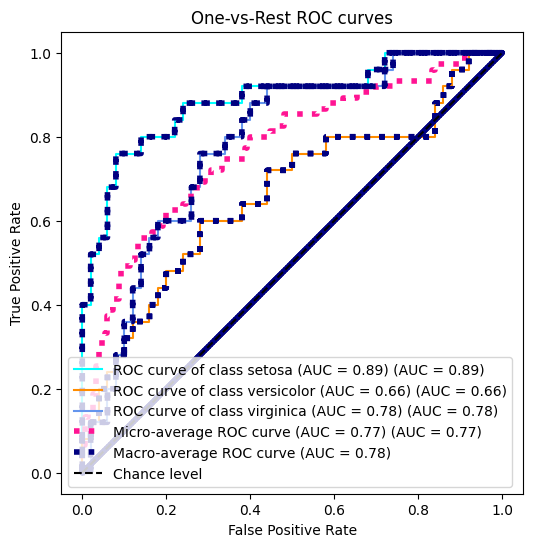

In [ ]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

## Binarize the target using the OvR strategy
label_binarizer = LabelBinarizer().fit(y_train)
y_onehot_val = label_binarizer.transform(y_test)

## Train a Logistic Regression model
classifier = LogisticRegression()
y_score = classifier.fit(X_train, y_train).predict_proba(X_test)

## Calculate ROC curve and ROC AUC score for each class
fpr, tpr, roc_auc = dict(), dict(), dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_onehot_val[:, i], y_score[:, i])
    roc_auc[i] = roc_auc_score(y_onehot_val[:, i], y_score[:, i])

## Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_onehot_val.ravel(), y_score.ravel())
roc_auc["micro"] = roc_auc_score(y_onehot_val, y_score, multi_class="ovr", average="micro")

## Compute macro-average ROC curve and ROC area
## Aggregate the true/false positive rates per class
fpr["macro"], tpr["macro"] = [], []
for i in range(n_classes):
    fpr_averaged, tpr_averaged = [], []
    for j in range(n_classes):
        if i != j:
            fpr_averaged += list(fpr[j])
            tpr_averaged += list(tpr[j])
    fpr_averaged = np.array(fpr_averaged)
    tpr_averaged = np.array(tpr_averaged)
    fpr["macro"].append(fpr_averaged)
    tpr["macro"].append(tpr_averaged)
fpr["macro"] = np.concatenate(fpr["macro"])
tpr["macro"] = np.concatenate(tpr["macro"])
roc_auc["macro"] = roc_auc_score(y_onehot_val, y_score, multi_class="ovr", average="macro")

## Plot ROC curves for each class and the micro/macro averages
fig, ax = plt.subplots(figsize=(6, 6))
colors = ["aqua", "darkorange", "cornflowerblue"]
for i, color in zip(range(n_classes), colors):
    RocCurveDisplay.from_predictions(
        y_onehot_val[:, i],
        y_score[:, i],
        name=f"ROC curve of class {target_names[i]} (AUC = {roc_auc[i]:.2f})",
        color=color,
        ax=ax
    )

RocCurveDisplay.from_predictions(
    y_onehot_val.ravel(),
    y_score.ravel(),
    name=f"Micro-average ROC curve (AUC = {roc_auc['micro']:.2f})",
    color="deeppink",
    linestyle=":",
    linewidth=4,
    ax=ax,
)

plt.plot(
    fpr["macro"],
    tpr["macro"],
    label=f"Macro-average ROC curve (AUC = {roc_auc['macro']:.2f})",
    color="navy",
    linestyle=":",
    linewidth=4,
)

plt.plot([0, 1], [0, 1], "k--", label="Chance level")
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC curves")
plt.legend()
plt.show()